# Basic Mean Reversion Strategy
This notebook implements the original ±1 Z-score mean reversion strategy on SPY.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download SPY data
data = yf.download("SPY", start="2018-01-01", end="2023-01-01")[['Close']]
data.columns = ['price']

[*********************100%***********************]  1 of 1 completed


In [3]:
window = 20
data['rolling_mean'] = data['price'].rolling(window).mean()
data['rolling_std'] = data['price'].rolling(window).std()
data['z_score'] = (data['price'] - data['rolling_mean']) / data['rolling_std']

In [6]:
data['signal'] = 0
data.loc[data['z_score'] < -1, 'signal'] = 1
data.loc[data['z_score'] > 1, 'signal'] = -1

In [8]:
data['position'] = data['signal'].shift(1).fillna(0)
data['returns'] = data['price'].pct_change()
data['strategy_returns'] = data['position'] * data['returns']

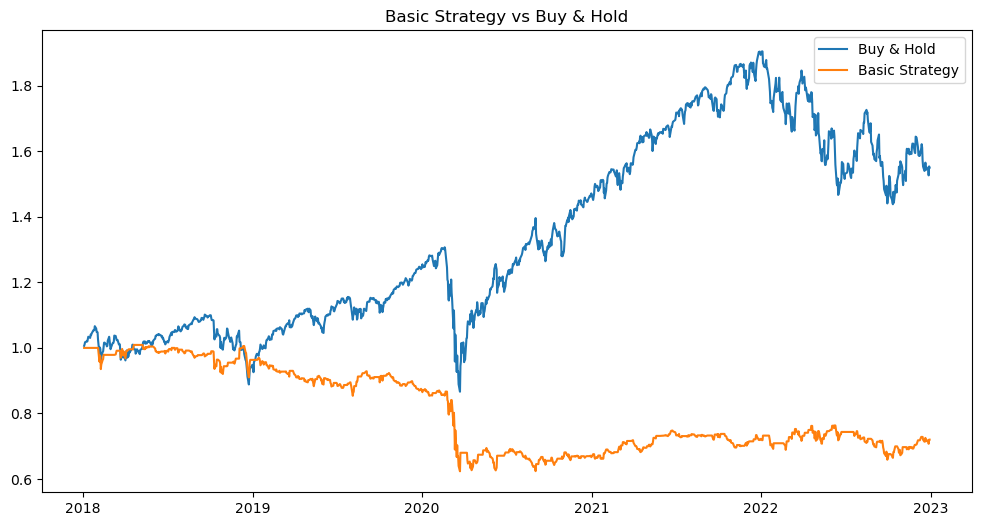

In [10]:
data['cumulative_returns'] = (1 + data['returns']).cumprod()
data['strategy_cumulative'] = (1 + data['strategy_returns']).cumprod()

plt.figure(figsize=(12,6))
plt.plot(data.index, data['cumulative_returns'], label='Buy & Hold')
plt.plot(data.index, data['strategy_cumulative'], label='Basic Strategy')
plt.legend()
plt.title('Basic Strategy vs Buy & Hold')
plt.show()

## Observations
- Strategy generates frequent signals due to ±1 Z-score threshold
- Performance can be volatile
- Useful for learning the pipeline of backtesting